# EDA and PCA

This notebook focuses on exploring the cleaned final dataset, producing EDA visuals, summarizing issues and assumptions made, and performing PCA on the data.

In [1]:
%pip install polars pyarrow pandas matplotlib scikit-learn jupyterlab

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import math
import re
import html

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(14)

polars.config.Config

## Paths


In [3]:
PROJECT_ROOT = Path.cwd().parent

FINAL_DATASET_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset_local_duckdb" / "social_platform_dataset_300k.parquet"
EDA_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "eda"
EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset path:", FINAL_DATASET_PATH)
print("Exists:", FINAL_DATASET_PATH.exists())
print("EDA output dir:", EDA_OUTPUT_DIR)

Dataset path: /Users/mhedlund/CIS2450/cis2450-final-project/data/processed/final_dataset_local_duckdb/social_platform_dataset_300k.parquet
Exists: True
EDA output dir: /Users/mhedlund/CIS2450/cis2450-final-project/outputs/eda


## Load the final dataset

In [4]:
df = pl.read_parquet(FINAL_DATASET_PATH)
print(df.shape)
df.head()

(300000, 18)


platform,post_id,author,text,created_at,likes,retweets,…,month,year_month,score,community,num_comments,upvote_ratio,parent_id
str,str,str,str,datetime[μs],i64,i64,…,i8,str,i64,str,i64,f64,str
"""hackernews""","""16628539""","""tandav""","""One note: fresh and clean airf…",2018-03-20 09:55:04,null,null,…,3,"""2018-03""",0,null,null,null,"""16628205"""
"""reddit""","""t3_106wnce""","""EmotionalCareer8069""","""This dude is wild on the wheel…",2023-01-08 00:00:00,null,null,…,1,"""2023-01""",1,"""simracing""",0,0.6,null
"""reddit""","""t3_14bnwb4""","""ejeje21""","""ktoś grupowe rp? None""",2023-06-17 00:00:00,null,null,…,6,"""2023-06""",1,"""BestPolishInfluencer""",2,1.0,null
"""hackernews""","""9792987""","""mahouse""",""">Can you really get a beer wit…",2015-06-28 05:46:19,null,null,…,6,"""2015-06""",0,null,null,null,"""9792869"""
"""hackernews""","""26604283""","""dhbradshaw""","""Really good idea. I'd like thi…",2021-03-27 14:26:27,null,null,…,3,"""2021-03""",0,null,null,null,"""26603097"""


## Basic schema and data review


In [5]:
df.schema

Schema([('platform', String),
        ('post_id', String),
        ('author', String),
        ('text', String),
        ('created_at', Datetime(time_unit='us', time_zone=None)),
        ('likes', Int64),
        ('retweets', Int64),
        ('replies', Int64),
        ('quotes', Int64),
        ('text_len', UInt32),
        ('year', Int32),
        ('month', Int8),
        ('year_month', String),
        ('score', Int64),
        ('community', String),
        ('num_comments', Int64),
        ('upvote_ratio', Float64),
        ('parent_id', String)])

In [6]:
df.group_by("platform").len().sort("platform")

platform,len
str,u32
"""hackernews""",100000
"""reddit""",100000
"""twitter""",100000


In [7]:
df.select([
    pl.len().alias("n_rows"),
    pl.col("text").is_null().sum().alias("null_text"),
    pl.col("author").is_null().sum().alias("null_author"),
    pl.col("created_at").is_null().sum().alias("null_created_at"),
    pl.col("text_len").mean().alias("mean_text_len"),
    pl.col("text_len").median().alias("median_text_len"),
    pl.col("text_len").min().alias("min_text_len"),
    pl.col("text_len").max().alias("max_text_len"),
])

n_rows,null_text,null_author,null_created_at,mean_text_len,median_text_len,min_text_len,max_text_len
u32,u32,u32,u32,f64,f64,u32,u32
300000,0,0,0,268.85462,134.0,20,39159


## Additional text features for EDA

These features are only for our initial analysis. The modeling notebooks will explicitly determine what features to keep and drop according to what we think will work the best.


In [8]:
def add_text_stats(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns([
        pl.col("text").str.count_matches(r"\?").alias("num_questions"),
        pl.col("text").str.count_matches(r"!").alias("num_exclamations"),
        pl.col("text").str.count_matches(r"#\w+").alias("num_hashtags"),
        pl.col("text").str.count_matches(r"@\w+").alias("num_mentions"),
        pl.col("text").str.count_matches(r"http[s]?://").alias("num_urls"),
        pl.col("text").str.count_matches(r"\d").alias("num_digits"),
        pl.col("text").str.count_matches(r"\b[A-Z]{2,}\b").alias("num_allcaps_words"),
        pl.col("text").str.count_matches(r"\b\w+\b").alias("num_words"),
    ]).with_columns([
        (pl.col("text_len") / pl.when(pl.col("num_words") > 0).then(pl.col("num_words")).otherwise(1)).alias("avg_word_len"),
    ])

eda_df = add_text_stats(df)
eda_df.head()

platform,post_id,author,text,created_at,likes,retweets,…,num_hashtags,num_mentions,num_urls,num_digits,num_allcaps_words,num_words,avg_word_len
str,str,str,str,datetime[μs],i64,i64,…,u32,u32,u32,u32,u32,u32,f64
"""hackernews""","""16628539""","""tandav""","""One note: fresh and clean airf…",2018-03-20 09:55:04,null,null,…,0,0,0,2,0,22,5.318182
"""reddit""","""t3_106wnce""","""EmotionalCareer8069""","""This dude is wild on the wheel…",2023-01-08 00:00:00,null,null,…,0,0,0,0,0,14,4.785714
"""reddit""","""t3_14bnwb4""","""ejeje21""","""ktoś grupowe rp? None""",2023-06-17 00:00:00,null,null,…,0,0,0,0,0,4,5.25
"""hackernews""","""9792987""","""mahouse""",""">Can you really get a beer wit…",2015-06-28 05:46:19,null,null,…,0,0,0,0,0,33,5.333333
"""hackernews""","""26604283""","""dhbradshaw""","""Really good idea. I'd like thi…",2021-03-27 14:26:27,null,null,…,0,0,0,0,0,11,4.727273


## Platform summary table

In [9]:
platform_summary = (
    eda_df.group_by("platform")
    .agg([
        pl.len().alias("n_rows"),
        pl.col("text_len").mean().alias("mean_text_len"),
        pl.col("text_len").median().alias("median_text_len"),
        pl.col("num_words").mean().alias("mean_num_words"),
        pl.col("num_questions").mean().alias("mean_num_questions"),
        pl.col("num_exclamations").mean().alias("mean_num_exclamations"),
        pl.col("num_hashtags").mean().alias("mean_num_hashtags"),
        pl.col("num_mentions").mean().alias("mean_num_mentions"),
        pl.col("num_urls").mean().alias("mean_num_urls"),
        pl.col("avg_word_len").mean().alias("mean_avg_word_len"),
    ])
    .sort("platform")
)

platform_summary

platform,n_rows,mean_text_len,median_text_len,mean_num_words,mean_num_questions,mean_num_exclamations,mean_num_hashtags,mean_num_mentions,mean_num_urls,mean_avg_word_len
str,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""hackernews""",100000,375.66357,246.0,67.84555,0.38087,0.08606,0.01814,0.0076,0.3373,5.532958
"""reddit""",100000,307.22964,90.0,56.40576,0.6538,0.32144,0.0549,0.01432,0.21978,5.508974
"""twitter""",100000,123.67065,107.0,19.23004,0.09769,0.29491,0.70177,0.71975,0.66524,7.27108


## Visual 1: class balance

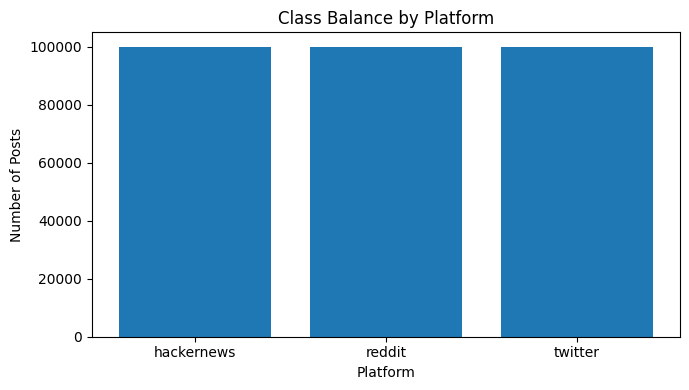

In [10]:
class_counts = eda_df.group_by("platform").len().sort("platform").to_pandas()

plt.figure(figsize=(7, 4))
plt.bar(class_counts["platform"], class_counts["len"])
plt.title("Class Balance by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.savefig(EDA_OUTPUT_DIR / "class_balance.png", dpi=150)
plt.show()

## Visual 2: text length distributions by platform

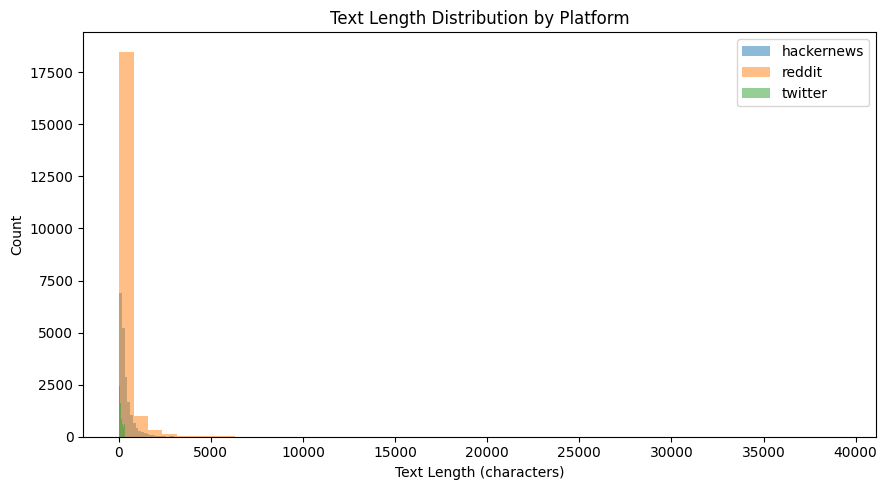

In [11]:
sample_for_hist = (
    eda_df.select(["platform", "text_len"])
    .sample(n=min(60000, eda_df.height), shuffle=True, seed=42)
    .to_pandas()
)

platforms = sorted(sample_for_hist["platform"].unique())

plt.figure(figsize=(9, 5))
for platform in platforms:
    vals = sample_for_hist.loc[sample_for_hist["platform"] == platform, "text_len"]
    plt.hist(vals, bins=50, alpha=0.5, label=platform)
plt.title("Text Length Distribution by Platform")
plt.xlabel("Text Length (characters)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig(EDA_OUTPUT_DIR / "text_length_hist.png", dpi=150)
plt.show()

## Visual 3: Stylistic markers by platform

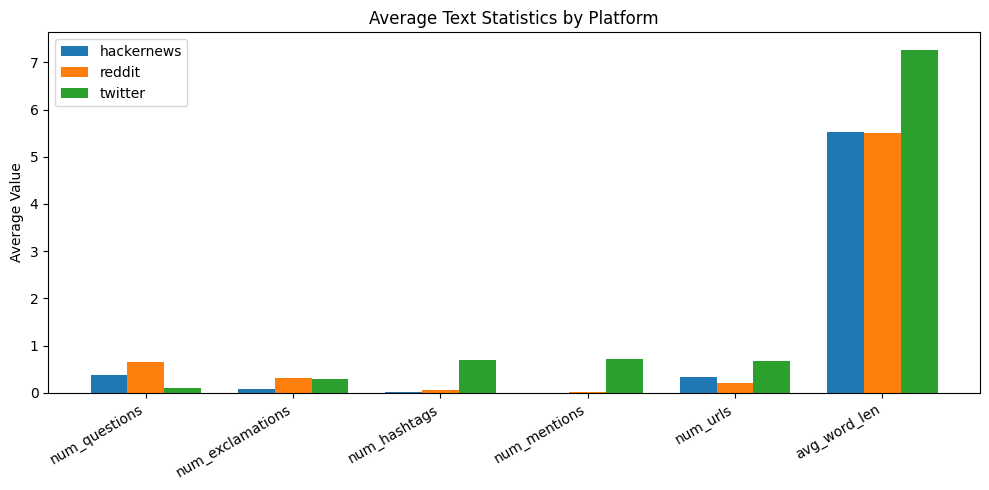

In [12]:
style_cols = [
    "num_questions",
    "num_exclamations",
    "num_hashtags",
    "num_mentions",
    "num_urls",
    "avg_word_len",
]

style_summary = eda_df.group_by("platform").agg(
    [pl.col(c).mean().alias(c) for c in style_cols]
).sort("platform").to_pandas()

x = np.arange(len(style_cols))
width = 0.25

plt.figure(figsize=(10, 5))
for i, platform in enumerate(style_summary["platform"]):
    plt.bar(x + i * width, style_summary.loc[i, style_cols], width=width, label=platform)

plt.xticks(x + width, style_cols, rotation=30, ha="right")
plt.title("Average Text Statistics by Platform")
plt.ylabel("Average Value")
plt.legend()
plt.tight_layout()
plt.savefig(EDA_OUTPUT_DIR / "style_stats_bar.png", dpi=150)
plt.show()

## visual 4: year-month activity

Note this is for analysis, but we will not use year-month data when modeling because it is unrelated to the text features we are interested in and the model could learn to classify based on the year-month data based on biases in our dataset.


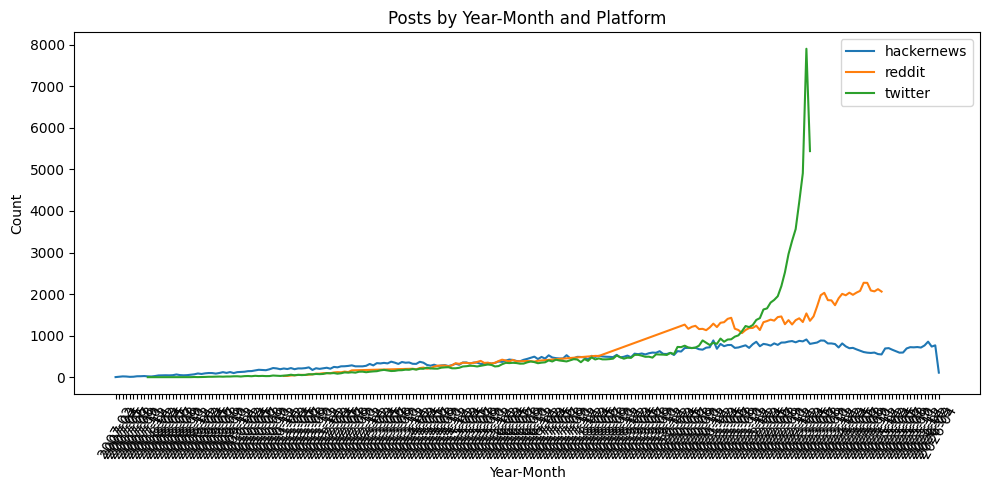

In [21]:
if "year_month" in eda_df.columns:
    ym_counts = (
        eda_df.group_by(["platform", "year_month"])
        .len()
        .sort(["platform", "year_month"])
        .to_pandas()
    )

    plt.figure(figsize=(10, 5))
    for platform in sorted(ym_counts["platform"].unique()):
        sub = ym_counts[ym_counts["platform"] == platform]
        plt.plot(sub["year_month"], sub["len"], label=platform)

    plt.title("Posts by Year-Month and Platform")
    plt.xlabel("Year-Month")
    plt.ylabel("Count")
    plt.xticks(rotation=60)
    plt.legend()
    plt.tight_layout()
    plt.savefig(EDA_OUTPUT_DIR / "year_month_counts.png", dpi=150)
    plt.show()
else:
    print("year_month column not found")

## PCA and clustering on engineered text statistics

We intentionally exclude features like created_at, year, month, year-month, IDs, authors, and metadata because those may encode platform/source artifacts instead of language style.


In [14]:
feature_cols = [
    "text_len",
    "num_questions",
    "num_exclamations",
    "num_hashtags",
    "num_mentions",
    "num_urls",
    "num_digits",
    "num_allcaps_words",
    "num_words",
    "avg_word_len",
]

stats_pdf = eda_df.select(["platform"] + feature_cols).to_pandas()
X_stats = stats_pdf[feature_cols].copy()
y_platform = stats_pdf["platform"].copy()

scaler = StandardScaler()
X_stats_scaled = scaler.fit_transform(X_stats)

pca = PCA(n_components=2, random_state=42)
X_pca_2d = pca.fit_transform(X_stats_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "platform": y_platform,
})

print("Explained variance ratio:", pca.explained_variance_ratio_)
pca_df.head()

Explained variance ratio: [0.32361807 0.13333784]


,PC1,PC2,platform
0,-0.527330,-0.436377,hackernews
1,-0.398583,-0.739212,reddit
2,-0.500085,-0.588636,reddit
3,-0.219739,-0.623927,hackernews
4,-0.656747,-0.593044,hackernews


## Visual 5: PCA of engineered text statistics

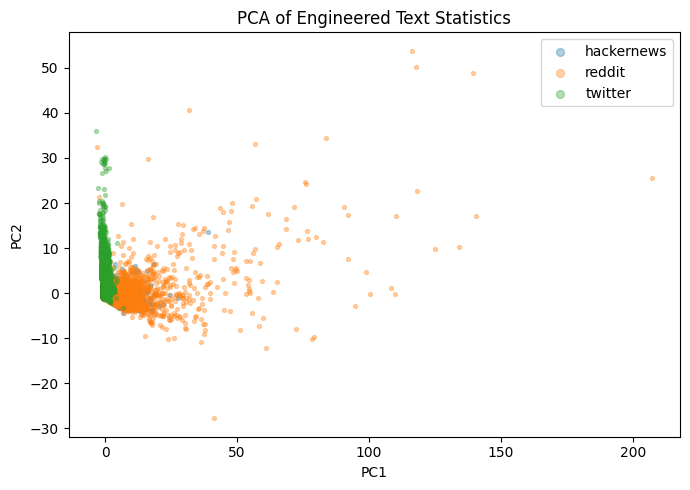

In [15]:
plt.figure(figsize=(7, 5))
for platform in sorted(pca_df["platform"].unique()):
    sub = pca_df[pca_df["platform"] == platform]
    plt.scatter(sub["PC1"], sub["PC2"], s=8, alpha=0.35, label=platform)

plt.title("PCA of Engineered Text Statistics")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(markerscale=2)
plt.tight_layout()
plt.savefig(EDA_OUTPUT_DIR / "pca_stats_scatter.png", dpi=150)
plt.show()